## 데이터프레임 생성

> ### **1-1 ) 14일간 훈련부하 데이터 생성**



In [1]:
import pandas as pd
import platform
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# 한글폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"

elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# Data
training = pd.DataFrame({
    "date": pd.date_range(
        "2026-09-01",
        periods=14
    ),
    "team_a": [
        100, 130, 90, 140, 110, 150, 120,
        160, 130, 170, 140, 180, 150, 190
    ],
    "team_b": [
        90, 110, 100, 120, 105, 130, 115,
        140, 120, 145, 130, 150, 140, 160
    ]
})

print(
    training.to_string(
        index=False
    )
)


      date  team_a  team_b
2026-09-01     100      90
2026-09-02     130     110
2026-09-03      90     100
2026-09-04     140     120
2026-09-05     110     105
2026-09-06     150     130
2026-09-07     120     115
2026-09-08     160     140
2026-09-09     130     120
2026-09-10     170     145
2026-09-11     140     130
2026-09-12     180     150
2026-09-13     150     140
2026-09-14     190     160


## **2. 선 그래프(Line Plot)**



> ### **2-1 ) plt.plot() 기본 사용**

#### "A팀의 일별 훈련부하를 선 그래프로 표현"

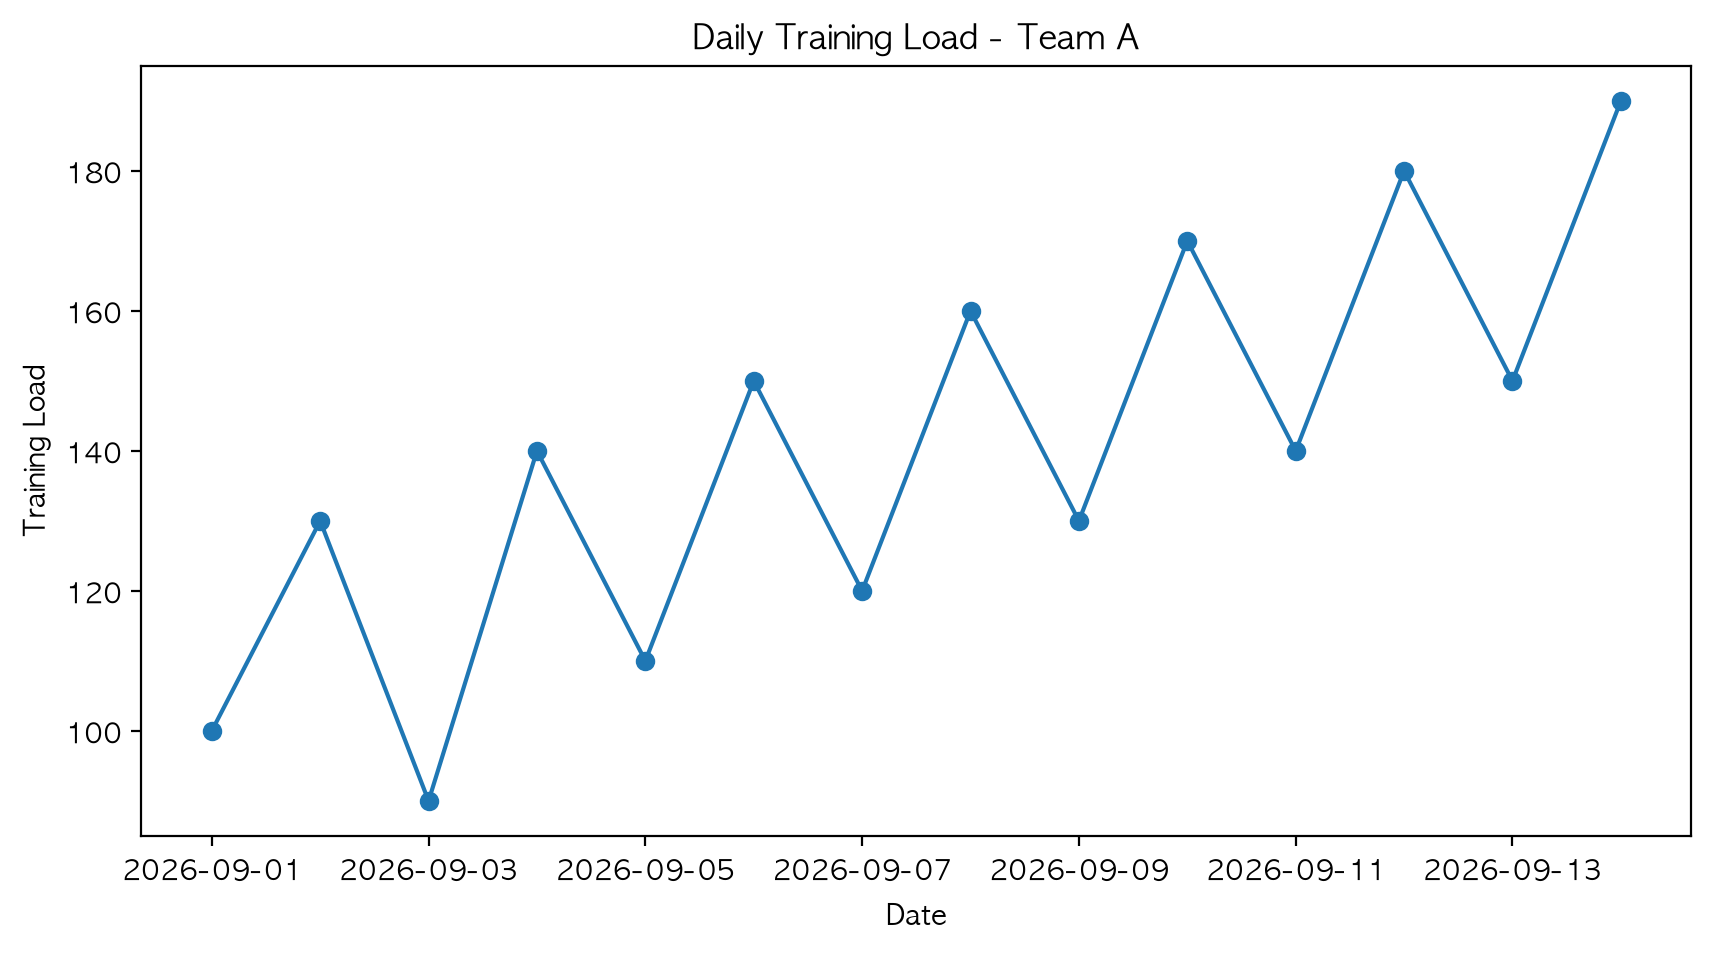

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    training["date"],
    training["team_a"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Training Load")
plt.title("Daily Training Load - Team A")

plt.show()

> ### **2-3 ) 선 그래프 스타일 옵션**



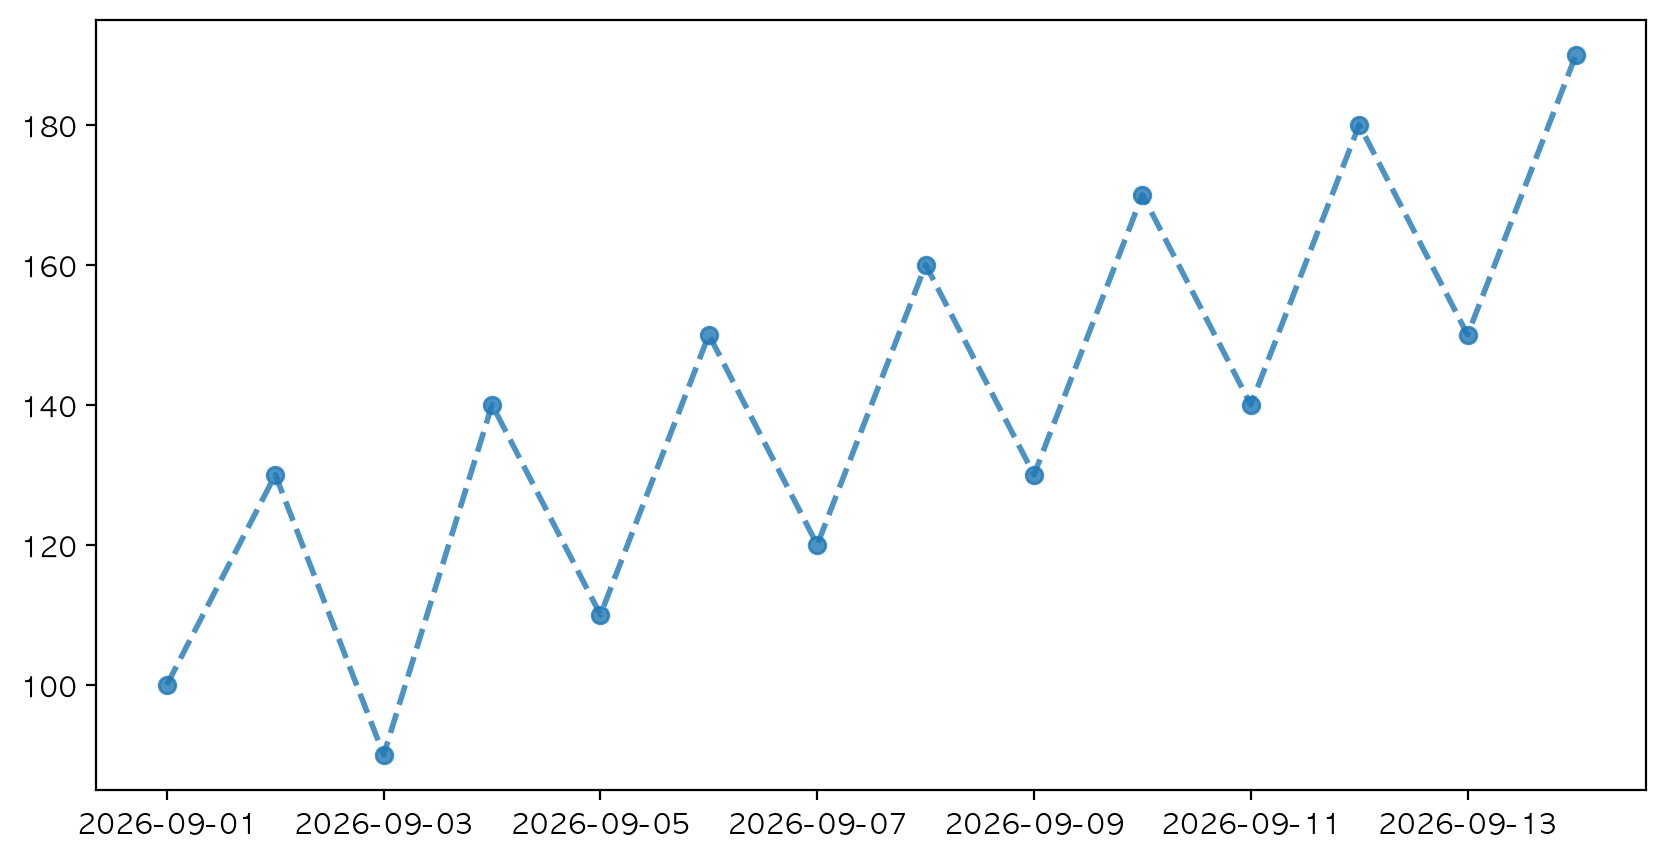

In [3]:
plt.figure(figsize=(10,5))

plt.plot(
    training["date"],
    training["team_a"],
    linestyle="--",
    marker="o",
    linewidth=2,
    alpha=0.8
)

## **3. 여러 선 비교와 차트 구성 요소**



> ### **3-1 ) A팀과 B팀의 훈련부하 비교**



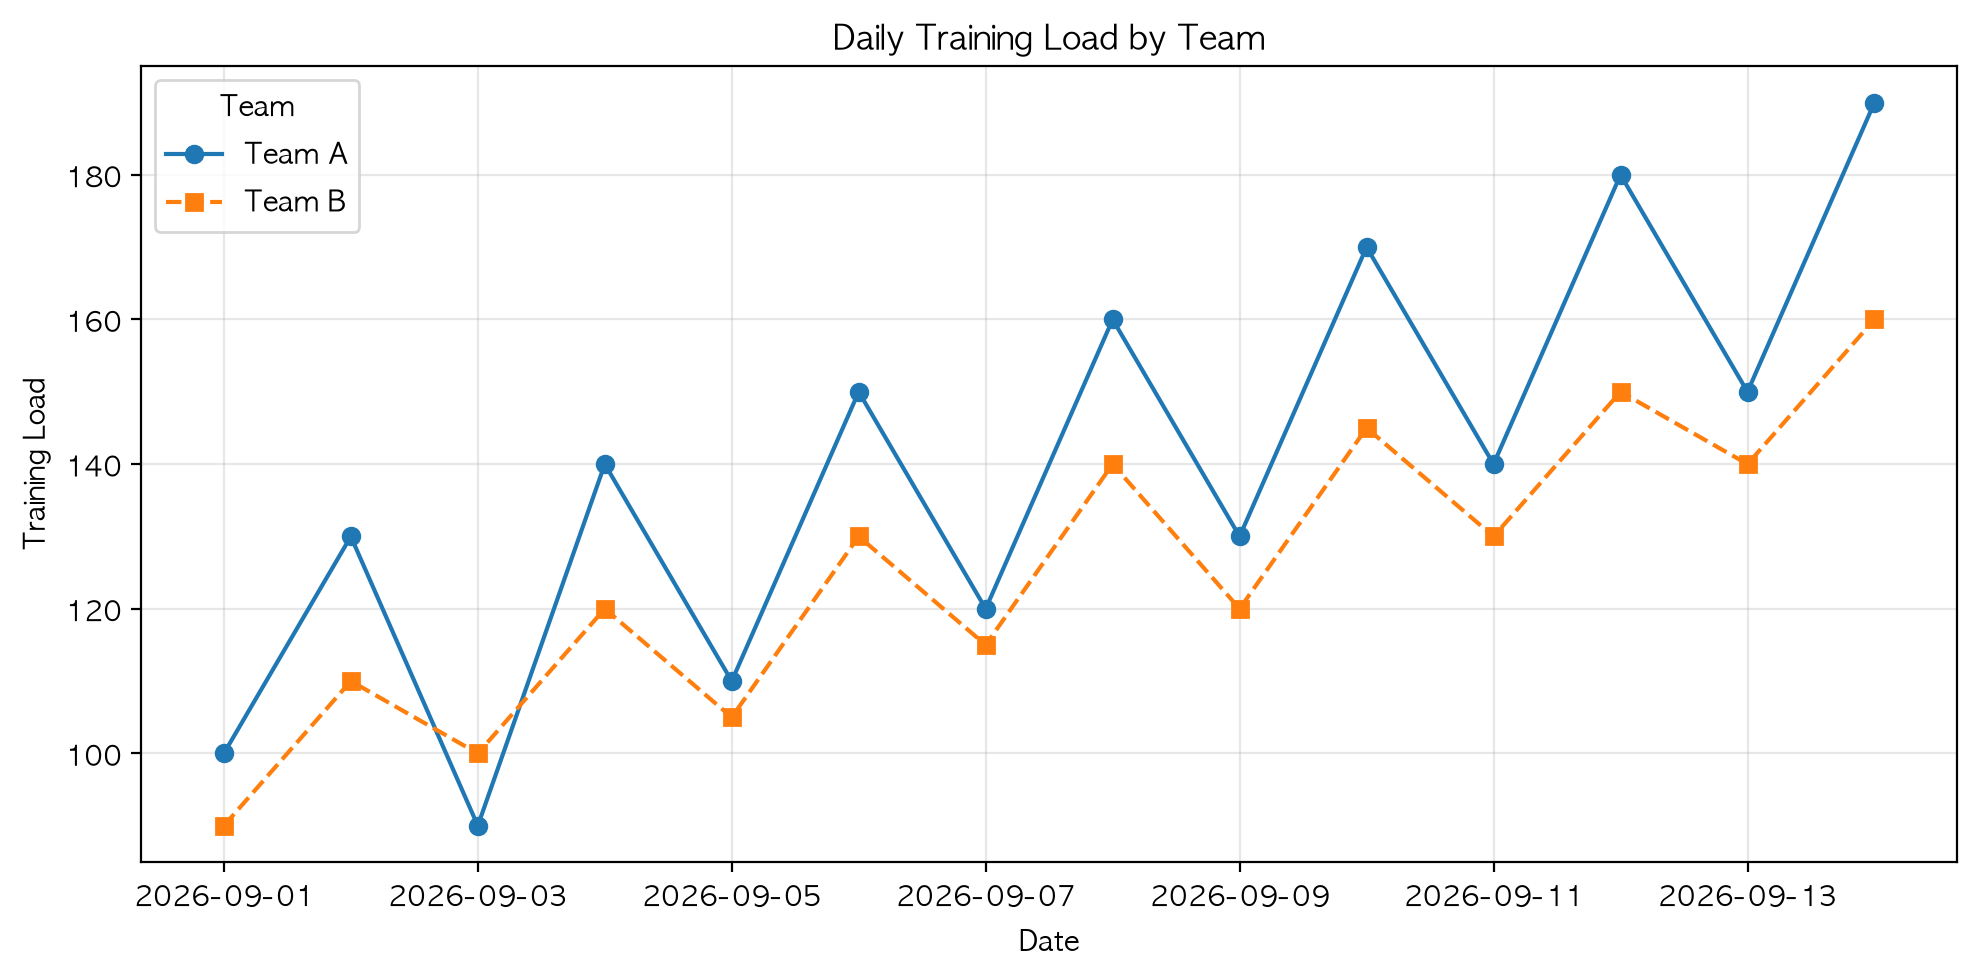

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    training["date"],
    training["team_a"],
    marker="o",
    label="Team A"
)

ax.plot(
    training["date"],
    training["team_b"],
    marker="s",
    linestyle="--",
    label="Team B"
)

ax.set_xlabel("Date")
ax.set_ylabel("Training Load")

ax.set_title(
    "Daily Training Load by Team"
)

ax.legend(
    title="Team"
)

ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

## **4. 이동평균(Moving Average)**



> ### **4-1 ) 3일 이동평균**



In [5]:
training["ma3"] = (
    training["team_a"]
    .rolling(
        window=3
    )
    .mean()
)

print(
    training[
        [
            "date",
            "team_a",
            "ma3"
        ]
    ].round(2).to_string(
        index=False
    )
)

      date  team_a    ma3
2026-09-01     100    NaN
2026-09-02     130    NaN
2026-09-03      90 106.67
2026-09-04     140 120.00
2026-09-05     110 113.33
2026-09-06     150 133.33
2026-09-07     120 126.67
2026-09-08     160 143.33
2026-09-09     130 136.67
2026-09-10     170 153.33
2026-09-11     140 146.67
2026-09-12     180 163.33
2026-09-13     150 156.67
2026-09-14     190 173.33


/var/folders/zv/9llt345s6_s_kw_bd93gb2jm0000gn/T/ipykernel_31091/2247411492.py:16: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2).to_string(


## **5. 원본 데이터와 이동평균 비교**



> ### **5-1 ) 원본 + 3일 이동평균**

#### "A팀 훈련부하와 3일 이동평균을 하나의 그래프에서 비교"


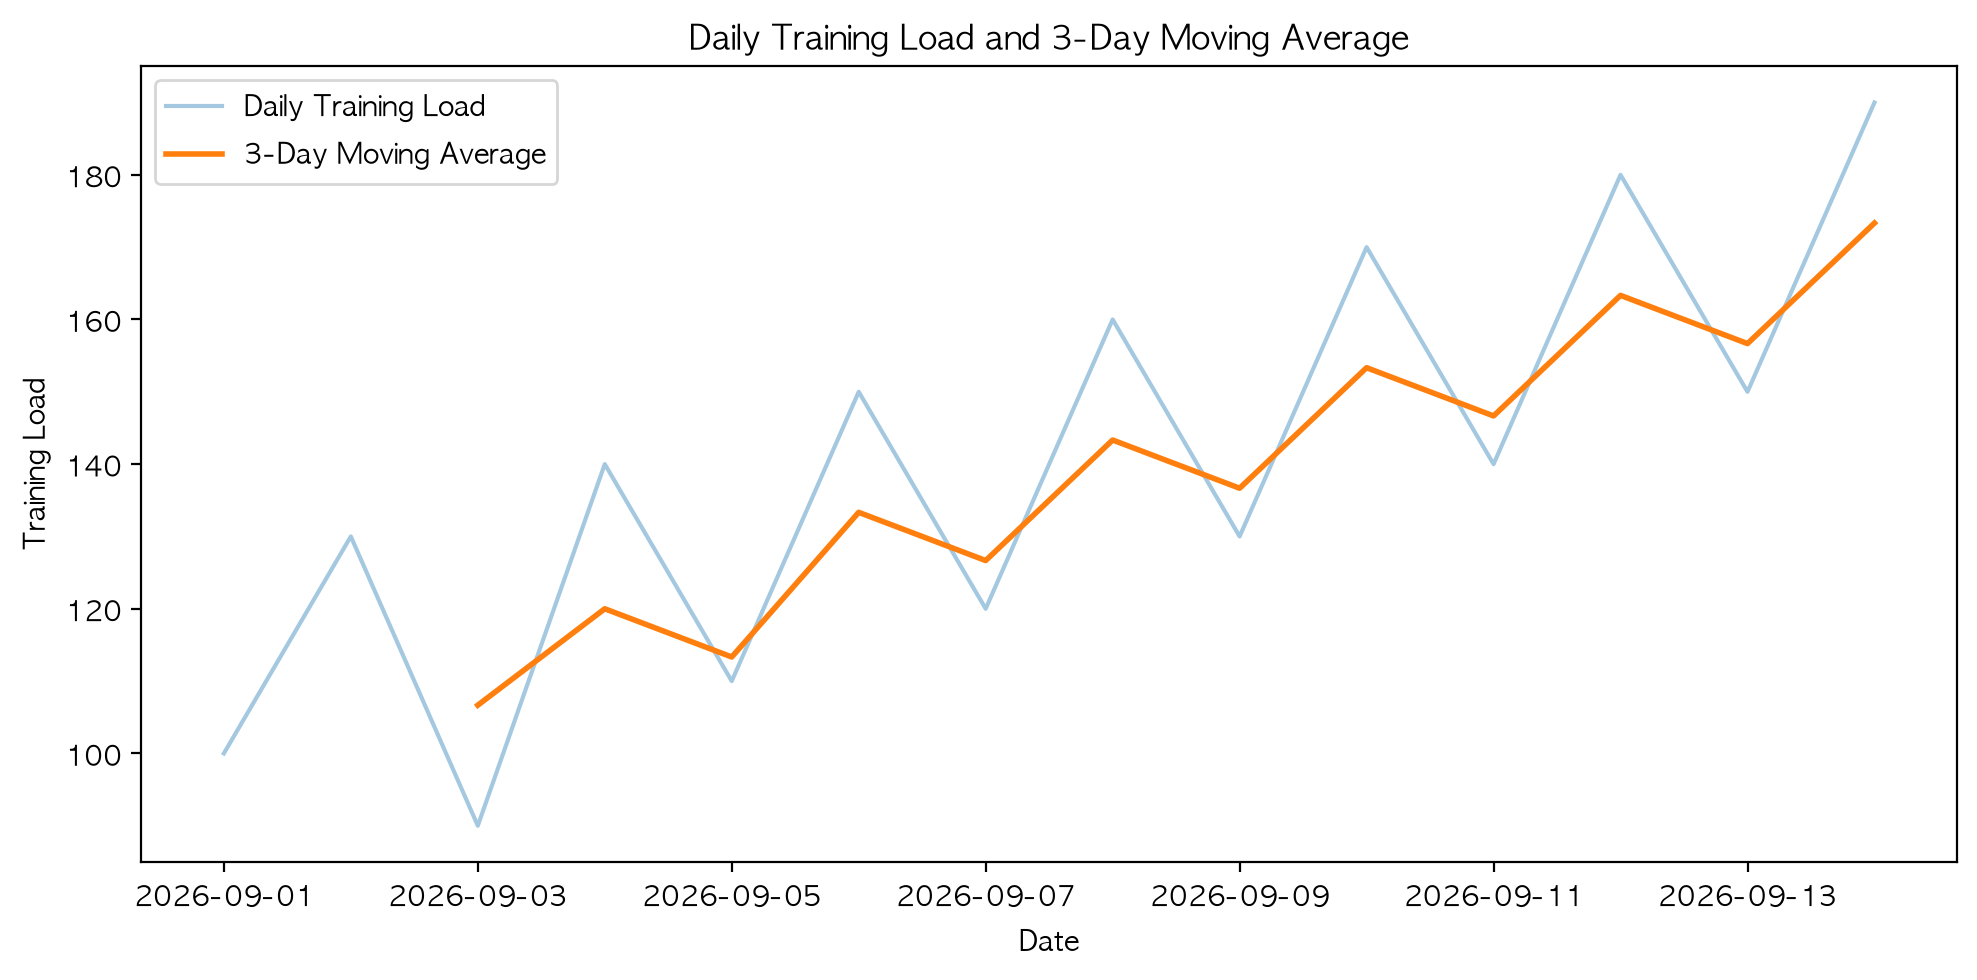

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    training["date"],
    training["team_a"],
    alpha=0.4,
    label="Daily Training Load"
)

ax.plot(
    training["date"],
    training["ma3"],
    linewidth=2,
    label="3-Day Moving Average"
)

ax.set_xlabel("Date")
ax.set_ylabel("Training Load")

ax.set_title(
    "Daily Training Load and 3-Day Moving Average"
)

ax.legend()

plt.tight_layout()
plt.show()

## **6. Window 크기에 따른 차이**



> ### **6-1 ) 3일 이동평균과 7일 이동평균**

#### "동일한 A팀 데이터에서 3일·7일 이동평균 비교"

In [7]:
training["ma3"] = (
    training["team_a"]
    .rolling(
        window=3
    )
    .mean()
)

training["ma7"] = (
    training["team_a"]
    .rolling(
        window=7
    )
    .mean()
)

print(
    training[
        [
            "date",
            "team_a",
            "ma3",
            "ma7"
        ]
    ].round(2).to_string(
        index=False
    )
)

      date  team_a    ma3    ma7
2026-09-01     100    NaN    NaN
2026-09-02     130    NaN    NaN
2026-09-03      90 106.67    NaN
2026-09-04     140 120.00    NaN
2026-09-05     110 113.33    NaN
2026-09-06     150 133.33    NaN
2026-09-07     120 126.67 120.00
2026-09-08     160 143.33 128.57
2026-09-09     130 136.67 128.57
2026-09-10     170 153.33 140.00
2026-09-11     140 146.67 140.00
2026-09-12     180 163.33 150.00
2026-09-13     150 156.67 150.00
2026-09-14     190 173.33 160.00


/var/folders/zv/9llt345s6_s_kw_bd93gb2jm0000gn/T/ipykernel_31091/2560871943.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2).to_string(


> ### **6-2 ) 원본 · MA3 · MA7 비교**



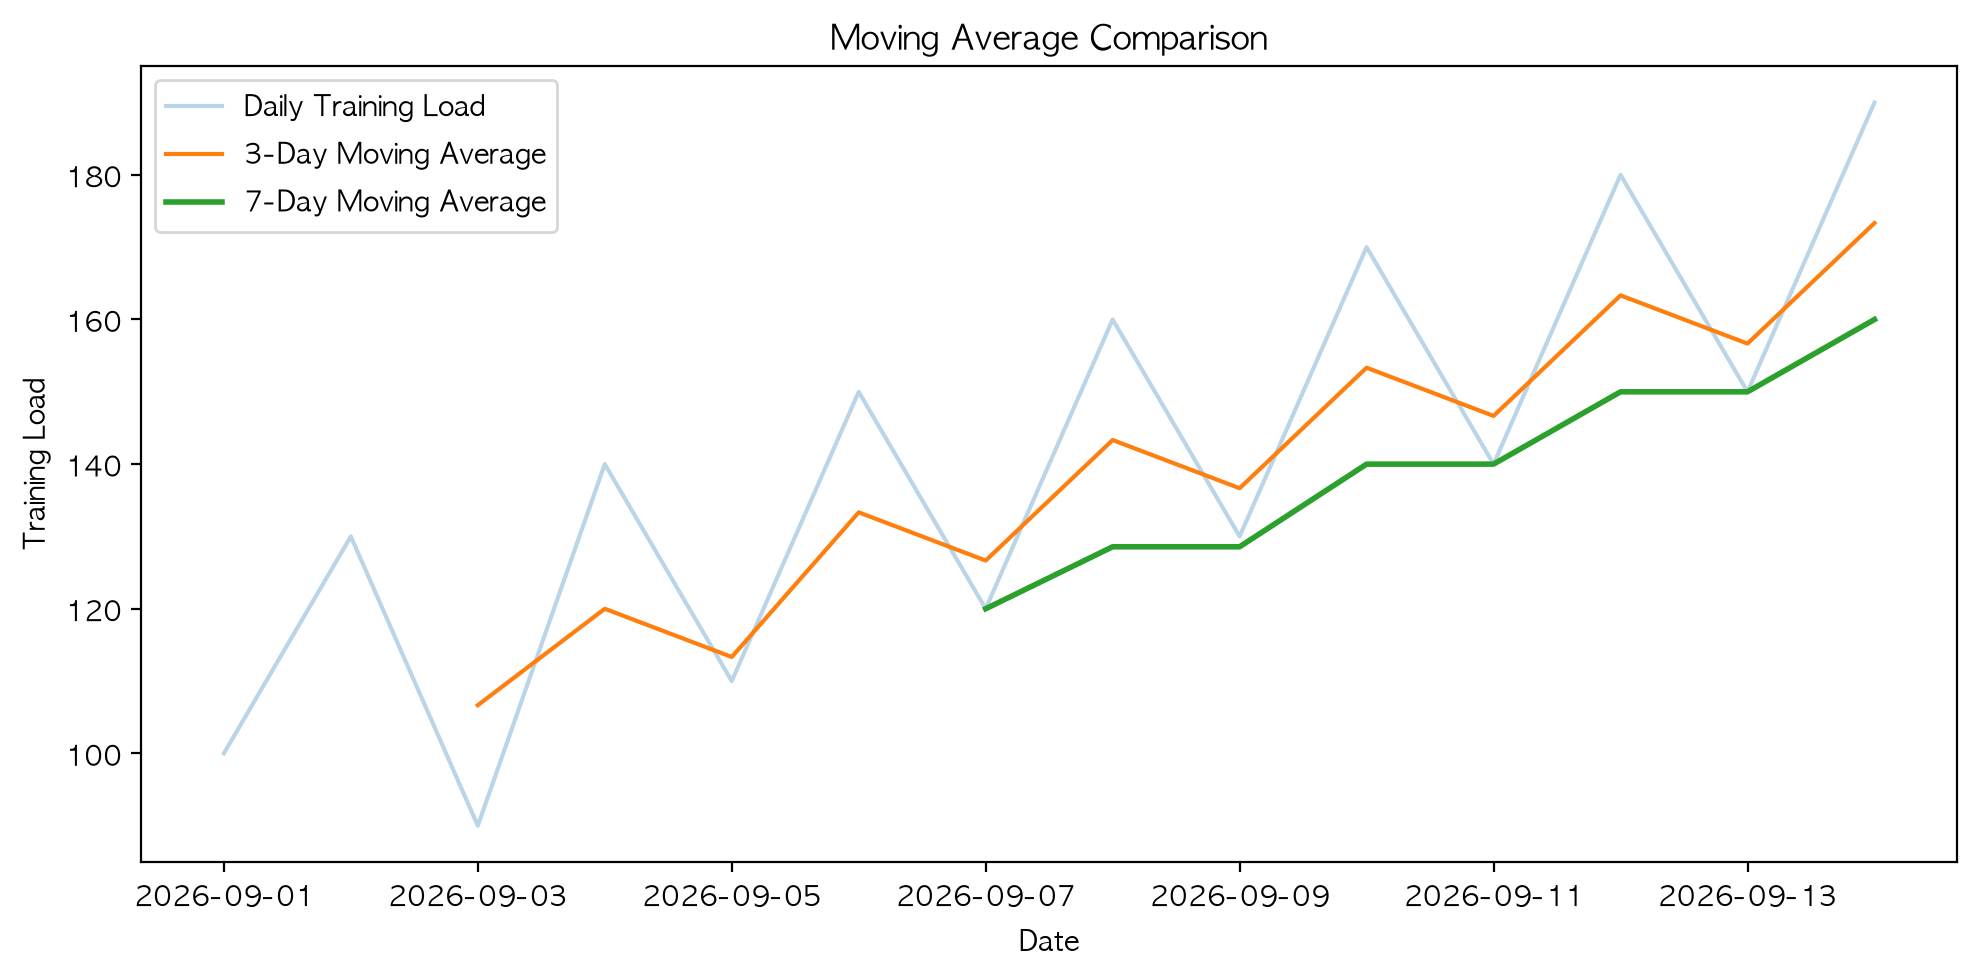

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    training["date"],
    training["team_a"],
    alpha=0.3,
    label="Daily Training Load"
)

ax.plot(
    training["date"],
    training["ma3"],
    label="3-Day Moving Average"
)

ax.plot(
    training["date"],
    training["ma7"],
    linewidth=2,
    label="7-Day Moving Average"
)

ax.set_xlabel("Date")
ax.set_ylabel("Training Load")

ax.set_title(
    "Moving Average Comparison"
)

ax.legend()

plt.tight_layout()
plt.show()